# Análisis exploratorio de terremotos — USGS

## Objetivo

Analizar el catálogo histórico global de terremotos obtenido mediante la API
del United States Geological Survey (USGS).

El dataset contiene terremotos:

- Desde 1900 hasta la fecha de ejecución.
- Con magnitud mínima de 4.5.
- Clasificados como `earthquake`.
- Con coordenadas, profundidad, magnitud y fecha válidas.

La descarga, limpieza y exportación reproducible se realiza mediante:

`src/usgs_earthquakes.py`

Este notebook se limita al análisis exploratorio, visualización y
documentación de conclusiones.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.graph_objects as go

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

# Detectar la raíz del proyecto tanto si el notebook se ejecuta desde
# la carpeta principal como desde la carpeta notebooks.
CURRENT_DIRECTORY = Path.cwd()

if (CURRENT_DIRECTORY / "src").exists():
    PROJECT_ROOT = CURRENT_DIRECTORY
else:
    PROJECT_ROOT = CURRENT_DIRECTORY.parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "usgs_earthquakes_clean.csv"
)

earthquakes = pd.read_csv(DATA_PATH)

# Las fechas se interpretan primero en UTC.
earthquakes["timestamp"] = pd.to_datetime(
    earthquakes["timestamp"],
    format="ISO8601",
    errors="coerce",
    utc=True,
)

earthquakes["updated_at"] = pd.to_datetime(
    earthquakes["updated_at"],
    format="ISO8601",
    errors="coerce",
    utc=True,
)

# La hora de Madrid se vuelve a generar para respetar automáticamente
# los cambios entre horario de invierno y horario de verano.
earthquakes["timestamp_madrid"] = (
    earthquakes["timestamp"]
    .dt.tz_convert("Europe/Madrid")
)

print(f"Archivo cargado: {DATA_PATH}")
print(f"Filas: {earthquakes.shape[0]:,}")
print(f"Columnas: {earthquakes.shape[1]}")
print(
    "Periodo:",
    earthquakes["timestamp"].min(),
    "→",
    earthquakes["timestamp"].max(),
)

display(earthquakes.head())

Archivo cargado: /mnt/hdd/David/2026/Formación/Somos_F5/Bootcam_Desarrollo_IA/Proyectos/Modulo3/2_Proyecto/GeoRisk_Finder/data/processed/usgs_earthquakes_clean.csv
Filas: 308,925
Columnas: 26
Periodo: 1900-01-31 19:22:00+00:00 → 2026-07-21 22:33:01.323000+00:00


,timestamp,lat,lon,depth_km,magnitude,magnitude_type,station_count,azimuthal_gap,nearest_station_distance,rms_error,network,event_id,updated_at,place,event_type,horizontal_error_km,depth_error_km,magnitude_error,magnitude_station_count,review_status,location_source,magnitude_source,timestamp_madrid,magnitude_scale_name,magnitude_category,source
0,1900-01-31 19:22:00+00:00,48.0,146.0,450.0,7.50,mj,NaN,NaN,NaN,NaN,cent,cent19000131192200000,2025-04-26 21:47:57.256000+00:00,Sea of Okhotsk,earthquake,NaN,NaN,NaN,NaN,reviewed,cent,cent,1900-01-31 19:07:16-00:14:44,Other or unspecified magnitude scale,major,USGS
1,1900-05-11 17:23:00+00:00,38.7,141.1,5.0,7.00,mj,NaN,NaN,NaN,NaN,cent,cent19000511172300000,2025-04-26 22:20:13.984000+00:00,"Northern Honshu, Japan",earthquake,NaN,NaN,NaN,NaN,reviewed,cent,cent,1900-05-11 17:08:16-00:14:44,Other or unspecified magnitude scale,major,USGS
2,1900-10-09 12:28:30+00:00,57.4,-151.0,20.0,7.86,mw,NaN,NaN,NaN,NaN,official,official19001009122400000,2024-12-31 01:27:41.842000+00:00,"Kodiak Island region, Alaska",earthquake,80.0,NaN,NaN,NaN,reviewed,official,pt,1900-10-09 12:13:46-00:14:44,Moment magnitude,major,USGS
3,1900-11-24 07:57:00+00:00,43.5,148.0,35.0,7.00,ms,NaN,NaN,NaN,NaN,cent,cent19001124075700000,2025-04-23 23:45:17.013000+00:00,Kuril Islands,earthquake,NaN,NaN,NaN,NaN,reviewed,cent,cent,1900-11-24 07:42:16-00:14:44,Surface-wave magnitude,major,USGS
4,1900-12-25 05:09:00+00:00,43.0,146.0,35.0,7.10,mw,NaN,NaN,NaN,NaN,cent,cent19001225050900000,2025-04-24 00:20:45.788000+00:00,"Off the coast of Hokkaido, Japan",earthquake,NaN,NaN,NaN,NaN,reviewed,cent,cent,1900-12-25 04:54:16-00:14:44,Moment magnitude,major,USGS


## Interpretación de la magnitud

La columna `magnitude` no representa necesariamente la escala de Richter.

El catálogo del USGS reúne terremotos cuya magnitud puede haber sido calculada
mediante distintos métodos. La columna `magnitude_type` identifica el método
utilizado para cada evento.

Algunos ejemplos presentes en el catálogo son:

- `ml`: magnitud local, conocida habitualmente como escala de Richter.
- `mb`: magnitud basada en ondas de cuerpo.
- `ms`: magnitud basada en ondas superficiales.
- `md`: magnitud de duración.
- `mw`, `mww`, `mwc`, `mwb` y `mwr`: variantes de la magnitud de momento.

Por tanto, el análisis utiliza `magnitude` como valor numérico comparable
dentro del catálogo, pero conserva siempre `magnitude_type` para no presentar
incorrectamente todos los registros como magnitudes Richter.

La columna `magnitude_scale_name` contiene una descripción comprensible del
método asociado a cada registro.

La columna `magnitude_category` (`light`, `moderate`, `strong`, etc.) es una
clasificación descriptiva añadida durante la limpieza. No sustituye al valor
numérico ni indica el método de cálculo de la magnitud.

In [2]:
magnitude_scales = (
    earthquakes
    .groupby(
        ["magnitude_type", "magnitude_scale_name"],
        dropna=False,
    )
    .size()
    .reset_index(name="event_count")
    .sort_values("event_count", ascending=False)
)

magnitude_scales["percentage"] = (
    magnitude_scales["event_count"]
    / len(earthquakes)
    * 100
).round(2)

display(magnitude_scales)

,magnitude_type,magnitude_scale_name,event_count,percentage
4,mb,Body-wave magnitude,232831,75.37
17,mw,Moment magnitude,26983,8.73
19,mwc,Moment magnitude,20370,6.59
22,mww,Moment magnitude,13919,4.51
15,ms,Surface-wave magnitude,4455,1.44
21,mwr,Moment magnitude,3476,1.13
18,mwb,Moment magnitude,3176,1.03
11,ml,Local magnitude (Richter),2430,0.79
8,md,Duration magnitude,807,0.26
2,m,Other or unspecified magnitude scale,302,0.10


## Calidad y estructura del dataset

Antes del análisis exploratorio se comprueba:

- El tipo de dato de cada columna.
- La cantidad y el porcentaje de valores ausentes.
- La existencia de identificadores duplicados.
- La validez de las columnas esenciales.
- Los rangos principales de magnitud, profundidad y coordenadas.

Los valores ausentes en columnas secundarias no se eliminan automáticamente,
ya que pueden aportar información parcial útil. Las columnas esenciales sí
deben estar completas.

In [3]:
quality_summary = pd.DataFrame(
    {
        "data_type": earthquakes.dtypes.astype(str),
        "non_null_count": earthquakes.notna().sum(),
        "missing_count": earthquakes.isna().sum(),
        "missing_percentage": (
            earthquakes.isna().mean() * 100
        ).round(2),
        "unique_values": earthquakes.nunique(dropna=True),
    }
)

display(quality_summary)

essential_columns = [
    "event_id",
    "timestamp",
    "lat",
    "lon",
    "depth_km",
    "magnitude",
]

print("Comprobaciones generales")
print("-" * 40)
print(f"Filas totales: {len(earthquakes):,}")
print(
    "Identificadores duplicados:",
    earthquakes["event_id"].duplicated().sum(),
)
print(
    "Nulos en columnas esenciales:",
    earthquakes[essential_columns].isna().sum().sum(),
)
print(
    "Latitudes válidas:",
    earthquakes["lat"].between(-90, 90).all(),
)
print(
    "Longitudes válidas:",
    earthquakes["lon"].between(-180, 180).all(),
)
print(
    f"Magnitud: {earthquakes['magnitude'].min():.1f}"
    f" → {earthquakes['magnitude'].max():.1f}"
)
print(
    f"Profundidad: {earthquakes['depth_km'].min():.2f}"
    f" → {earthquakes['depth_km'].max():.2f} km"
)

,data_type,non_null_count,missing_count,missing_percentage,unique_values
timestamp,"datetime64[us, UTC]",308925,0,0.00,308923
lat,float64,308925,0,0.00,173211
lon,float64,308925,0,0.00,201800
depth_km,float64,308925,0,0.00,34074
magnitude,float64,308925,0,0.00,367
magnitude_type,str,308924,1,0.00,24
station_count,float64,119512,189413,61.31,739
azimuthal_gap,float64,169571,139354,45.11,2779
nearest_station_distance,float64,96322,212603,68.82,17376
rms_error,float64,259882,49043,15.88,446


Comprobaciones generales
----------------------------------------
Filas totales: 308,925
Identificadores duplicados: 0
Nulos en columnas esenciales: 0
Latitudes válidas: True
Longitudes válidas: True
Magnitud: 4.5 → 9.5
Profundidad: -3.00 → 700.90 km


### Nota sobre las profundidades negativas

El dataset contiene una profundidad mínima de `-3.0 km`.

Este valor no significa que el terremoto se haya producido físicamente por
encima de la superficie terrestre. En terremotos muy superficiales, la
profundidad es difícil de estimar con precisión y puede aparecer como negativa
debido a:

- La incertidumbre del cálculo de la localización.
- La referencia vertical utilizada por cada red sísmica.
- Las diferencias entre el geoide, el nivel medio del mar y la elevación
  de las estaciones.

El catálogo USGS ComCat combina información procedente de distintas redes
sísmicas, por lo que no todas las profundidades se calculan mediante el mismo
método.

Por este motivo, las profundidades negativas se conservan en el dataset y se
interpretan como estimaciones de eventos muy superficiales, no como errores
que deban eliminarse automáticamente.

In [4]:
numeric_summary = earthquakes[
    [
        "magnitude",
        "depth_km",
        "lat",
        "lon",
        "station_count",
        "azimuthal_gap",
        "rms_error",
        "horizontal_error_km",
        "depth_error_km",
        "magnitude_error",
    ]
].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).T

numeric_summary["missing_count"] = earthquakes[
    numeric_summary.index
].isna().sum()

numeric_summary["missing_percentage"] = (
    earthquakes[numeric_summary.index].isna().mean() * 100
).round(2)

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max,missing_count,missing_percentage
magnitude,308925.0,4.932846,0.481695,4.5000,4.600,4.8000,5.1000,5.60000,5.91000,6.690000,9.500,0,0.00
depth_km,308925.0,68.963703,115.107109,-3.0000,10.000,33.0000,60.5000,155.00000,300.00000,596.360520,700.900,0,0.00
lat,308925.0,4.259376,29.578770,-84.1330,-17.537,0.8208,29.6080,44.32500,51.93692,62.882520,87.386,0,0.00
lon,308925.0,43.076956,120.518425,-179.9997,-70.938,100.6520,142.4684,160.22006,168.10186,178.858304,180.000,0,0.00
station_count,119512.0,79.991792,88.596893,0.0000,27.000,50.0000,97.0000,180.00000,261.00000,454.890000,934.000,189413,61.31
azimuthal_gap,169571.0,94.798036,47.023108,6.5000,59.500,89.7000,123.2000,154.00000,180.05000,233.000000,360.000,139354,45.11
rms_error,259882.0,0.924858,0.327147,-1.0000,0.750,0.9200,1.1000,1.26000,1.35000,1.500000,69.320,49043,15.88
horizontal_error_km,89257.0,8.430428,3.656839,0.0000,6.360,8.1300,10.3000,12.40000,13.80000,15.860000,99.000,219668,71.11
depth_error_km,173221.0,9.799974,886.817669,-1.0000,1.900,5.3000,8.8000,16.40000,25.00000,36.800000,367558.100,135704,43.93
magnitude_error,111643.0,0.126826,0.102716,0.0000,0.065,0.0970,0.1530,0.22000,0.31000,0.570000,1.840,197282,63.86


### Lectura inicial del resumen estadístico

La mayoría de los terremotos del catálogo se concentra cerca de la magnitud
mínima seleccionada:

- El 50 % tiene magnitud igual o inferior a 4.8.
- El 75 % tiene magnitud igual o inferior a 5.1.
- El 99 % tiene magnitud igual o inferior a aproximadamente 6.69.
- Los terremotos de magnitud muy alta son poco frecuentes dentro del catálogo.

Respecto a la profundidad:

- La mediana es de 33 km.
- El 75 % de los eventos se sitúa hasta aproximadamente 60.5 km.
- Existe una cola de terremotos profundos que alcanza unos 700 km.

Las columnas relacionadas con la calidad de la localización no están completas
para todo el periodo histórico. Algunas presentan más de un 60 % de valores
ausentes, por lo que no deben utilizarse como variables obligatorias sin un
tratamiento específico.

También se observan posibles valores anómalos en las métricas de error. Antes
de eliminarlos o transformarlos, se analizarán sus frecuencias y los registros
con valores extremos.

In [5]:
quality_metric_columns = [
    "rms_error",
    "horizontal_error_km",
    "depth_error_km",
    "magnitude_error",
]

secondary_quality_summary = pd.DataFrame(
    {
        "non_null_count": earthquakes[
            quality_metric_columns
        ].notna().sum(),
        "missing_percentage": (
            earthquakes[quality_metric_columns].isna().mean() * 100
        ).round(2),
        "negative_count": (
            earthquakes[quality_metric_columns] < 0
        ).sum(),
        "zero_count": (
            earthquakes[quality_metric_columns] == 0
        ).sum(),
        "median": earthquakes[
            quality_metric_columns
        ].median(),
        "percentile_99": earthquakes[
            quality_metric_columns
        ].quantile(0.99),
        "maximum": earthquakes[
            quality_metric_columns
        ].max(),
    }
)

display(secondary_quality_summary)

print("Registros con mayor error de profundidad")
display(
    earthquakes.nlargest(
        10,
        "depth_error_km",
    )[
        [
            "event_id",
            "timestamp",
            "place",
            "depth_km",
            "depth_error_km",
            "network",
            "review_status",
        ]
    ]
)

,non_null_count,missing_percentage,negative_count,zero_count,median,percentile_99,maximum
rms_error,259882,15.88,20,22,0.920,1.50,69.32
horizontal_error_km,89257,71.11,0,37,8.130,15.86,99.00
depth_error_km,173221,43.93,20,1781,5.300,36.80,367558.10
magnitude_error,111643,63.86,0,31,0.097,0.57,1.84


Registros con mayor error de profundidad


,event_id,timestamp,place,depth_km,depth_error_km,network,review_status
181546,ak009akg6mrr,2009-08-18 04:33:01.838000+00:00,"Komandorskiye Ostrova, Russia region",27.5,367558.1,ak,reviewed
180905,ak0098qa256o,2009-07-09 03:27:54.564000+00:00,"Komandorskiye Ostrova, Russia region",20.8,33206.4,ak,reviewed
181265,ak0099qntz2z,2009-07-31 03:19:12.599000+00:00,"Komandorskiye Ostrova, Russia region",9.8,4121.5,ak,reviewed
182063,ak009cbe2s4k,2009-09-25 10:16:03.568000+00:00,"145 km NNW of Diomede, Alaska",15.8,1172.4,ak,reviewed
142374,ak003er1rb0d,2003-11-17 10:49:30.531000+00:00,"Rat Islands, Aleutian Islands, Alaska",40.5,1091.9,ak,reviewed
138895,ak0033jinwn4,2003-03-18 10:55:28.328000+00:00,south of the Aleutian Islands,19.5,1053.7,ak,reviewed
185460,ak0102wg3473,2010-03-04 15:50:15.675000+00:00,"Rat Islands, Aleutian Islands, Alaska",13.7,791.3,ak,reviewed
138879,ak0033i0dn3h,2003-03-17 19:37:46.377000+00:00,"Rat Islands, Aleutian Islands, Alaska",1.2,744.1,ak,reviewed
140940,ak003apq3l1r,2003-08-21 23:31:50.230000+00:00,"119 km WNW of Arctic Village, Alaska",20.7,725.8,ak,reviewed
176557,ak008d6z98dk,2008-10-13 20:18:47.445000+00:00,"54 km E of Red Dog Mine, Alaska",13.7,612.5,ak,reviewed


### Calidad de las métricas auxiliares

Las variables esenciales del análisis —fecha, localización, profundidad y
magnitud— están completas. Sin embargo, las métricas técnicas relacionadas con
la incertidumbre no tienen una cobertura homogénea:

- `horizontal_error_km` tiene un 71.11 % de valores ausentes.
- `magnitude_error` tiene un 63.86 % de valores ausentes.
- `depth_error_km` tiene un 43.93 % de valores ausentes.
- `rms_error` tiene un 15.88 % de valores ausentes.

También aparecen valores negativos en `rms_error` y `depth_error_km`. Como una
medida de error no debería ser negativa, estos valores no se utilizarán en
análisis estadísticos de calidad.

La columna `depth_error_km` contiene además algunos valores extremadamente
altos. El máximo es de 367,558.1 km, muy alejado de su mediana de 5.3 km y de
su percentil 99 de 36.8 km.

Estos valores se conservan en el dataset para mantener la trazabilidad de la
fuente original, pero no se interpretarán como observaciones representativas.
Cuando se visualicen las métricas de error se utilizarán límites robustos,
como el percentil 99, sin eliminar el evento sísmico completo.

,magnitude_category,event_count,percentage
0,light,202934,65.69
1,moderate,91663,29.67
2,strong,12748,4.13
3,major,1480,0.48
4,great,100,0.03


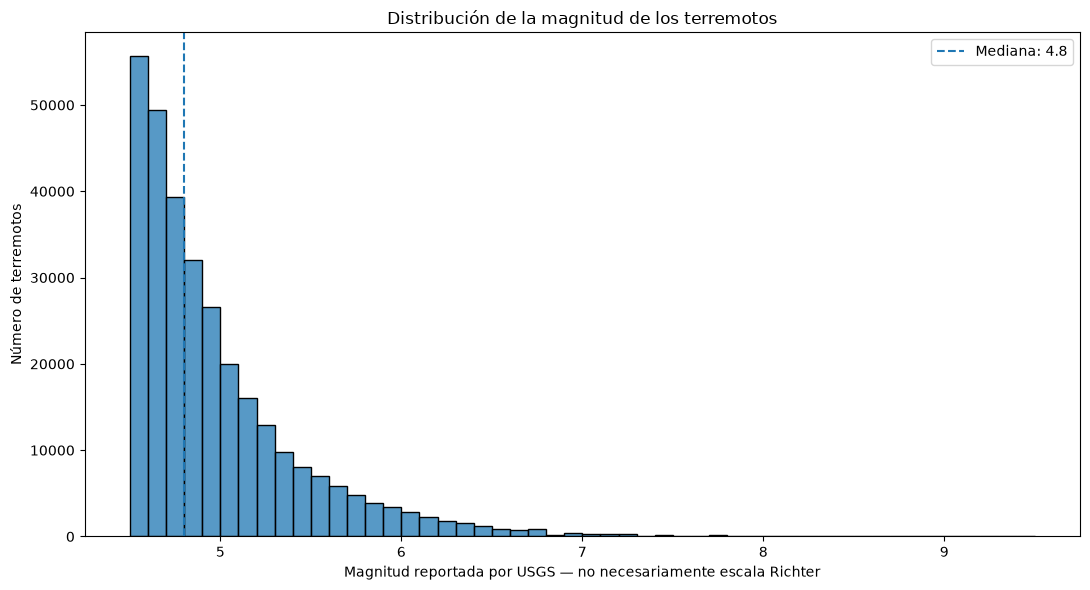

In [6]:
magnitude_category_order = [
    "light",
    "moderate",
    "strong",
    "major",
    "great",
]

magnitude_category_summary = (
    earthquakes
    .groupby("magnitude_category", dropna=False)
    .size()
    .reindex(magnitude_category_order, fill_value=0)
    .rename("event_count")
    .reset_index()
)

magnitude_category_summary["percentage"] = (
    magnitude_category_summary["event_count"]
    / len(earthquakes)
    * 100
).round(2)

display(magnitude_category_summary)


median_magnitude = earthquakes["magnitude"].median()

fig, ax = plt.subplots(figsize=(11, 6))

sns.histplot(
    data=earthquakes,
    x="magnitude",
    binwidth=0.1,
    ax=ax,
)

ax.axvline(
    median_magnitude,
    linestyle="--",
    label=f"Mediana: {median_magnitude:.1f}",
)

ax.set_title("Distribución de la magnitud de los terremotos")
ax.set_xlabel(
    "Magnitud reportada por USGS — no necesariamente escala Richter"
)
ax.set_ylabel("Número de terremotos")
ax.legend()

plt.tight_layout()
plt.show()

### Interpretación de la distribución de magnitudes

La distribución está fuertemente concentrada cerca del límite mínimo de
magnitud establecido para la descarga:

- El 65.69 % de los eventos pertenece a la categoría `light`.
- El 29.67 % pertenece a la categoría `moderate`.
- En conjunto, el 95.36 % tiene una magnitud inferior a 6.0.
- Los eventos `major` y `great` representan únicamente el 0.51 %.

Esto no significa que los terremotos de menor magnitud sean necesariamente más
frecuentes en la naturaleza en esta misma proporción. El dataset está
condicionado por el umbral de magnitud 4.5 y por los cambios históricos en la
capacidad de detección y registro.

Las categorías describen intervalos del valor numérico de magnitud. No
identifican el método utilizado para calcularla. Para ello debe consultarse
`magnitude_type`; únicamente `ml` corresponde a la magnitud local asociada
habitualmente con la escala de Richter.

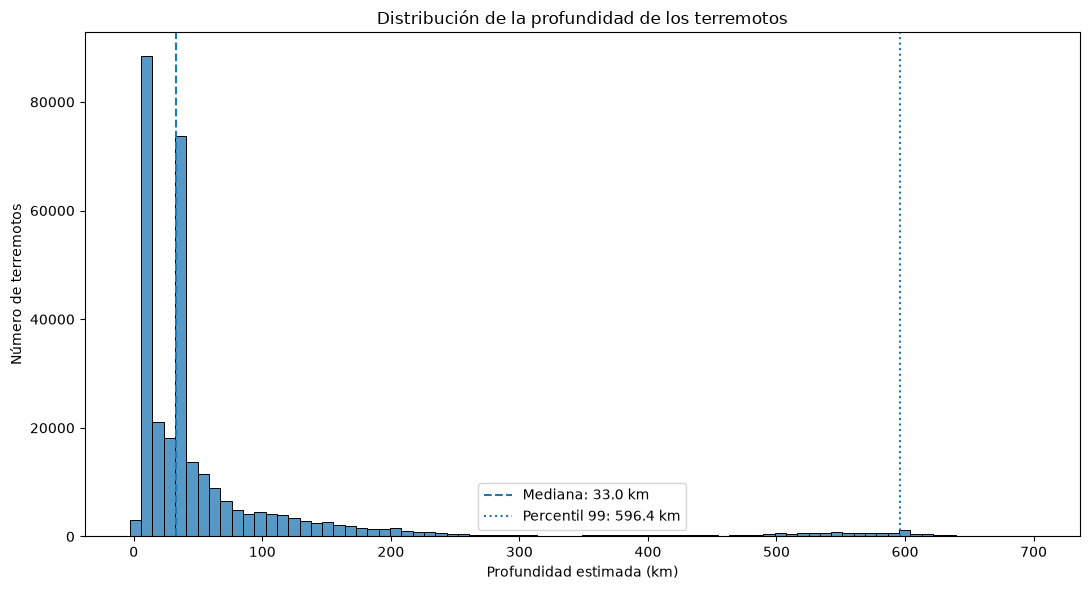

,depth_range,event_count,percentage
0,negative_or_zero,267,0.09
1,shallow_0_70_km,240539,77.86
2,intermediate_70_300_km,52738,17.07
3,deep_over_300_km,15381,4.98


In [7]:
depth_median = earthquakes["depth_km"].median()
depth_percentile_99 = earthquakes["depth_km"].quantile(0.99)

fig, ax = plt.subplots(figsize=(11, 6))

sns.histplot(
    data=earthquakes,
    x="depth_km",
    bins=80,
    ax=ax,
)

ax.axvline(
    depth_median,
    linestyle="--",
    label=f"Mediana: {depth_median:.1f} km",
)

ax.axvline(
    depth_percentile_99,
    linestyle=":",
    label=f"Percentil 99: {depth_percentile_99:.1f} km",
)

ax.set_title("Distribución de la profundidad de los terremotos")
ax.set_xlabel("Profundidad estimada (km)")
ax.set_ylabel("Número de terremotos")
ax.legend()

plt.tight_layout()
plt.show()


depth_ranges = pd.cut(
    earthquakes["depth_km"],
    bins=[
        float("-inf"),
        0,
        70,
        300,
        float("inf"),
    ],
    labels=[
        "negative_or_zero",
        "shallow_0_70_km",
        "intermediate_70_300_km",
        "deep_over_300_km",
    ],
    right=True,
)

depth_summary = (
    depth_ranges
    .value_counts(sort=False)
    .rename("event_count")
    .reset_index()
    .rename(columns={"depth_km": "depth_range"})
)

depth_summary["percentage"] = (
    depth_summary["event_count"]
    / len(earthquakes)
    * 100
).round(2)

display(depth_summary)

### Interpretación de la distribución de profundidades

La mayor parte del catálogo está formada por terremotos relativamente
superficiales:

- El 77.86 % se encuentra entre más de 0 y 70 km.
- El 17.07 % se encuentra entre más de 70 y 300 km.
- El 4.98 % supera los 300 km de profundidad.
- El 0.09 % presenta una profundidad igual o inferior a 0 km.

En conjunto, el 77.95 % de los eventos tiene una profundidad igual o inferior
a 70 km.

La mediana de profundidad es de 33 km, mientras que el valor medio es de
aproximadamente 69 km. La diferencia entre ambos valores se debe a la cola de
terremotos profundos, que eleva la media.

Los valores iguales o inferiores a cero se conservan porque pueden estar
relacionados con eventos muy superficiales, incertidumbre de localización o
diferencias en la referencia vertical utilizada por las redes sísmicas.

Los intervalos de profundidad se utilizan aquí como categorías descriptivas
para facilitar el análisis. La variable numérica original `depth_km` se
conserva sin reemplazar.

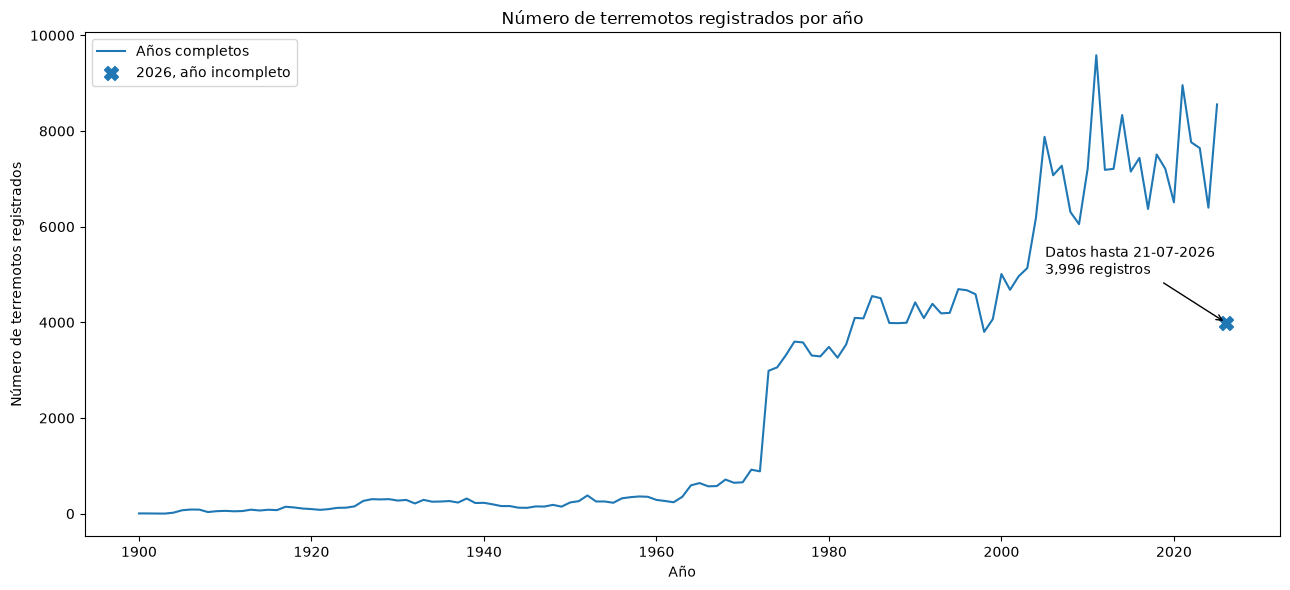

In [8]:
earthquakes["year"] = earthquakes["timestamp"].dt.year

annual_summary = (
    earthquakes
    .groupby("year")
    .agg(
        event_count=("event_id", "size"),
        mean_magnitude=("magnitude", "mean"),
        median_magnitude=("magnitude", "median"),
        maximum_magnitude=("magnitude", "max"),
        median_depth_km=("depth_km", "median"),
    )
    .reset_index()
)

last_timestamp = earthquakes["timestamp"].max()
last_year = last_timestamp.year

completed_years = annual_summary[
    annual_summary["year"] < last_year
].copy()

partial_year = annual_summary[
    annual_summary["year"] == last_year
].copy()


fig, ax = plt.subplots(figsize=(13, 6))

sns.lineplot(
    data=completed_years,
    x="year",
    y="event_count",
    ax=ax,
    label="Años completos",
)

ax.scatter(
    partial_year["year"],
    partial_year["event_count"],
    marker="X",
    s=100,
    label=f"{last_year}, año incompleto",
)

if not partial_year.empty:
    partial_count = int(partial_year["event_count"].iloc[0])

    ax.annotate(
        (
            f"Datos hasta "
            f"{last_timestamp.strftime('%d-%m-%Y')}\n"
            f"{partial_count:,} registros"
        ),
        xy=(
            int(partial_year["year"].iloc[0]),
            partial_count,
        ),
        xytext=(-130, 35),
        textcoords="offset points",
        arrowprops={"arrowstyle": "->"},
    )

ax.set_title(
    "Número de terremotos registrados por año"
)
ax.set_xlabel("Año")
ax.set_ylabel("Número de terremotos registrados")
ax.legend()

plt.tight_layout()
plt.show()

### Interpretación de la evolución temporal

La aparente caída observada en 2026 no representa necesariamente una
disminución de la actividad sísmica.

El dataset contiene información de 2026 solamente hasta el 21 de julio, por
lo que este año no es directamente comparable con los años completos
anteriores. Por ese motivo, se representa con un marcador diferente.

Además, la evolución del número de registros no debe interpretarse únicamente
como una evolución de la actividad sísmica mundial. El catálogo histórico
abarca desde 1900, pero la capacidad para detectar, localizar y registrar
terremotos ha cambiado considerablemente durante ese periodo.

El crecimiento del número de registros puede estar influido por:

- La ampliación de las redes de estaciones sísmicas.
- Las mejoras en los instrumentos de detección.
- La digitalización y consolidación de catálogos históricos.
- Los cambios en la cobertura geográfica.
- La revisión y actualización de eventos por distintas redes.

Por tanto, esta gráfica describe la cantidad de registros disponibles en el
catálogo USGS, no demuestra por sí sola que actualmente ocurran más o menos
terremotos que en décadas anteriores.

## Distribución geográfica de los terremotos

Las coordenadas permiten observar dónde se concentran los terremotos
registrados en el catálogo.

Para evitar el solapamiento de más de 300,000 puntos, los eventos se agrupan
en una cuadrícula geográfica de un grado. El tamaño y el color de cada marcador
representan la concentración de registros de esa zona.

La escala de densidad es logarítmica, lo que permite visualizar tanto las
zonas con pocos registros como las regiones con una concentración muy alta.

Esta visualización representa la distribución de los terremotos del catálogo,
pero no constituye por sí sola un mapa de riesgo. El riesgo geológico también
depende de factores como la exposición de población e infraestructuras, la
vulnerabilidad y las características locales del terreno.

In [9]:
# Tamaño de la cuadrícula geográfica en grados.
GRID_SIZE_DEGREES = 1.0

geographic_density = (
    earthquakes
    .assign(
        lat_grid=(
            earthquakes["lat"] / GRID_SIZE_DEGREES
        ).round() * GRID_SIZE_DEGREES,
        lon_grid=(
            earthquakes["lon"] / GRID_SIZE_DEGREES
        ).round() * GRID_SIZE_DEGREES,
    )
    .groupby(
        ["lat_grid", "lon_grid"],
        as_index=False,
    )
    .agg(
        event_count=("event_id", "size"),
        mean_magnitude=("magnitude", "mean"),
    )
)

# Se utiliza una escala logarítmica porque existen grandes diferencias
# entre las zonas con pocos registros y las de mayor concentración.
geographic_density["log_event_count"] = np.log10(
    geographic_density["event_count"]
)

geographic_density["marker_size"] = np.clip(
    np.log1p(geographic_density["event_count"]) * 2,
    2,
    16,
)

fig = go.Figure(
    go.Scattergeo(
        lon=geographic_density["lon_grid"],
        lat=geographic_density["lat_grid"],
        mode="markers",
        customdata=geographic_density[
            [
                "event_count",
                "mean_magnitude",
            ]
        ],
        marker={
            "size": geographic_density["marker_size"],
            "color": geographic_density["log_event_count"],
            "colorscale": "Viridis",
            "opacity": 0.75,
            "line": {"width": 0},
            "colorbar": {
                "title": "log10(registros)",
            },
        },
        hovertemplate=(
            "Latitud: %{lat:.1f}<br>"
            "Longitud: %{lon:.1f}<br>"
            "Registros: %{customdata[0]:,.0f}<br>"
            "Magnitud media: %{customdata[1]:.2f}"
            "<extra></extra>"
        ),
    )
)

fig.update_geos(
    projection_type="natural earth",
    showland=True,
    landcolor="rgb(238, 238, 238)",
    showocean=True,
    oceancolor="rgb(220, 235, 245)",
    showcoastlines=True,
    coastlinecolor="rgb(90, 90, 90)",
    showcountries=True,
    countrycolor="rgb(160, 160, 160)",
    showframe=True,
    lataxis_range=[-90, 90],
    lonaxis_range=[-180, 180],
)

fig.update_layout(
    title={
        "text": (
            "Distribución geográfica global de los "
            "terremotos registrados"
        ),
        "x": 0.5,
    },
    height=700,
    margin={
        "l": 20,
        "r": 20,
        "t": 70,
        "b": 20,
    },
)

fig.show()

### Interpretación de la distribución geográfica

Los terremotos no aparecen distribuidos uniformemente por el planeta. Se
observan concentraciones alargadas que siguen principalmente los límites entre
placas tectónicas.

Destacan especialmente:

- El borde del océano Pacífico.
- La costa occidental de América.
- Japón, Filipinas, Indonesia y Nueva Zelanda.
- La región mediterránea y parte de Asia.
- Las dorsales oceánicas.

El mapa representa la densidad de registros del catálogo USGS. No debe
interpretarse directamente como un mapa de riesgo, ya que el riesgo también
depende de la población expuesta, las infraestructuras, la vulnerabilidad y
otros factores locales.

In [10]:
largest_earthquakes = (
    earthquakes
    .sort_values(
        ["magnitude", "timestamp"],
        ascending=[False, True],
    )
    [
        [
            "event_id",
            "timestamp",
            "place",
            "magnitude",
            "magnitude_type",
            "magnitude_scale_name",
            "depth_km",
            "lat",
            "lon",
        ]
    ]
    .head(15)
    .reset_index(drop=True)
)

largest_earthquakes.index = largest_earthquakes.index + 1
largest_earthquakes.index.name = "rank"

display(largest_earthquakes)

,event_id,timestamp,place,magnitude,magnitude_type,magnitude_scale_name,depth_km,lat,lon
rank,,,,,,,,,
1,official19600522191120_30,1960-05-22 19:11:20+00:00,1960 Great Chilean Earthquake (Valdivia Earthquake),9.5,mw,Moment magnitude,25.0,-38.1430,-73.4070
2,official19640328033616_30,1964-03-28 03:36:16+00:00,"The 1964 Prince William Sound, Alaska Earthquake",9.2,mw,Moment magnitude,25.0,60.9080,-147.3390
3,official20041226005853450_30,2004-12-26 00:58:53.450000+00:00,2004 Sumatra - Andaman Islands Earthquake,9.1,mw,Moment magnitude,30.0,3.2950,95.9820
4,official20110311054624120_30,2011-03-11 05:46:24.120000+00:00,"2011 Great Tohoku Earthquake, Japan",9.1,mww,Moment magnitude,29.0,38.2970,142.3730
5,official19521104165830_30,1952-11-04 16:58:30+00:00,"89 km ESE of Petropavlovsk-Kamchatsky, Russia",9.0,mw,Moment magnitude,21.6,52.6230,159.7790
6,official19060131153610_30,1906-01-31 15:36:10+00:00,1906 Ecuador-Colombia Earthquake,8.8,mw,Moment magnitude,20.0,0.9550,-79.3690
7,official20100227063411530_30,2010-02-27 06:34:11.530000+00:00,"2010 Maule, Chile Earthquake",8.8,mww,Moment magnitude,22.9,-36.1220,-72.8980
8,us6000qw60,2025-07-29 23:24:52.483000+00:00,"2025 Kamchatka Peninsula, Russia Earthquake",8.8,mww,Moment magnitude,35.0,52.4948,160.2395
9,official19650204050122_30,1965-02-04 05:01:22+00:00,1965 Western Aleutian Islands (Hawadax/Rat Islands) Earthquake,8.7,mw,Moment magnitude,30.3,51.2510,178.7150


### Terremotos de mayor magnitud

Los eventos de mayor magnitud del catálogo fueron calculados mediante
magnitud de momento:

- El terremoto de Valdivia de 1960 alcanza una magnitud de 9.5.
- El terremoto de Alaska de 1964 alcanza una magnitud de 9.2.
- Los terremotos de Sumatra de 2004 y Tohoku de 2011 alcanzan una magnitud
  de 9.1.
- El terremoto de Kamchatka de 1952 alcanza una magnitud de 9.0.

En los cinco primeros registros, `magnitude_type` es `mw` o `mww`. Ambos
pertenecen a la familia de la magnitud de momento.

Esto vuelve a demostrar que no es correcto describir todos los valores del
catálogo como magnitudes en la escala de Richter. La columna `magnitude`
contiene el valor reportado, mientras que `magnitude_type` identifica el
método utilizado para calcularlo.

,magnitude_type,magnitude_scale_name,event_count,percentage
4,mb,Body-wave magnitude,232831,75.37
17,mw,Moment magnitude,26983,8.73
19,mwc,Moment magnitude,20370,6.59
22,mww,Moment magnitude,13919,4.51
15,ms,Surface-wave magnitude,4455,1.44
21,mwr,Moment magnitude,3476,1.13
18,mwb,Moment magnitude,3176,1.03
11,ml,Local magnitude (Richter),2430,0.79
8,md,Duration magnitude,807,0.26
2,m,Other or unspecified magnitude scale,302,0.10


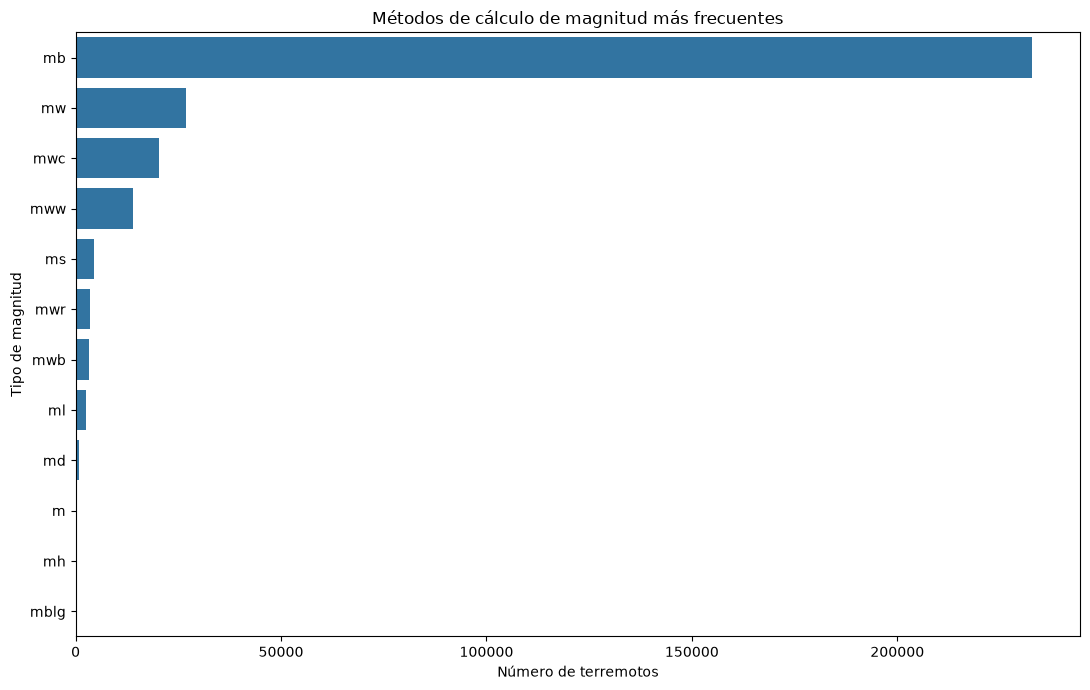

Eventos con magnitud local (ml, asociada a Richter): 2,430
Porcentaje del catálogo: 0.79%


In [11]:
magnitude_type_summary = (
    earthquakes
    .groupby(
        ["magnitude_type", "magnitude_scale_name"],
        dropna=False,
    )
    .size()
    .reset_index(name="event_count")
    .sort_values("event_count", ascending=False)
)

magnitude_type_summary["percentage"] = (
    magnitude_type_summary["event_count"]
    / len(earthquakes)
    * 100
).round(2)

display(magnitude_type_summary)


top_magnitude_types = magnitude_type_summary.head(12)

fig, ax = plt.subplots(figsize=(11, 7))

sns.barplot(
    data=top_magnitude_types,
    y="magnitude_type",
    x="event_count",
    ax=ax,
)

ax.set_title(
    "Métodos de cálculo de magnitud más frecuentes"
)
ax.set_xlabel("Número de terremotos")
ax.set_ylabel("Tipo de magnitud")

plt.tight_layout()
plt.show()


local_magnitude_count = (
    earthquakes["magnitude_type"]
    .eq("ml")
    .sum()
)

local_magnitude_percentage = (
    local_magnitude_count
    / len(earthquakes)
    * 100
)

print(
    "Eventos con magnitud local (ml, asociada a Richter):",
    f"{local_magnitude_count:,}",
)

print(
    "Porcentaje del catálogo:",
    f"{local_magnitude_percentage:.2f}%",
)

### Interpretación de los métodos de magnitud

El catálogo utiliza diferentes métodos para calcular la magnitud de los
terremotos.

El método más frecuente es `mb`, basado en ondas de cuerpo, que representa
el 75.37 % de los registros.

Las principales variantes de magnitud de momento identificadas (`mw`, `mwc`,
`mww`, `mwr` y `mwb`) representan conjuntamente aproximadamente el 21.99 %
del catálogo.

En cambio, solamente el 0.79 % de los eventos utiliza `ml`, magnitud local
asociada habitualmente con la escala de Richter.

Por tanto, no es correcto afirmar que las magnitudes de este dataset estén
expresadas únicamente en la escala de Richter. La columna `magnitude`
contiene el valor numérico reportado, mientras que `magnitude_type` indica
el método utilizado para obtenerlo.

Existe también un único registro sin un tipo de magnitud especificado. Este
evento se conserva porque su magnitud numérica y sus demás variables
esenciales son válidas.

,magnitude_scale_name,event_count,percentage
0,Body-wave magnitude,232831,75.37
3,Moment magnitude,67924,21.99
5,Surface-wave magnitude,4455,1.44
2,Local magnitude (Richter),2430,0.79
1,Duration magnitude,807,0.26
4,Other or unspecified magnitude scale,478,0.15


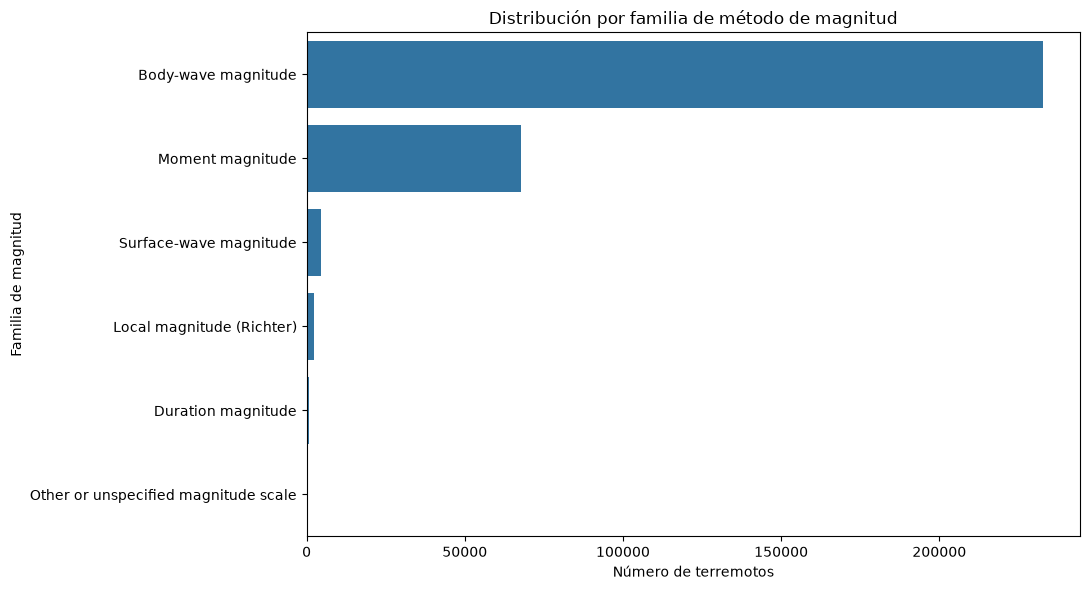

In [12]:
magnitude_family_summary = (
    earthquakes
    .groupby(
        "magnitude_scale_name",
        dropna=False,
    )
    .size()
    .reset_index(name="event_count")
    .sort_values(
        "event_count",
        ascending=False,
    )
)

magnitude_family_summary["percentage"] = (
    magnitude_family_summary["event_count"]
    / len(earthquakes)
    * 100
).round(2)

display(magnitude_family_summary)


fig, ax = plt.subplots(figsize=(11, 6))

sns.barplot(
    data=magnitude_family_summary,
    y="magnitude_scale_name",
    x="event_count",
    ax=ax,
)

ax.set_title(
    "Distribución por familia de método de magnitud"
)
ax.set_xlabel("Número de terremotos")
ax.set_ylabel("Familia de magnitud")

plt.tight_layout()
plt.show()

### Conclusión sobre las escalas de magnitud

La agrupación por familias confirma que el catálogo no utiliza una única
escala de magnitud:

- El 75.37 % corresponde a magnitud basada en ondas de cuerpo.
- El 21.99 % corresponde a variantes de magnitud de momento.
- El 1.44 % corresponde a magnitud basada en ondas superficiales.
- Solo el 0.79 % corresponde a magnitud local, asociada habitualmente con
  la escala de Richter.
- El resto utiliza magnitud de duración u otros métodos menos frecuentes.

En consecuencia, el 99.21 % de los registros no utiliza la magnitud local
`ml`. Por ello, a lo largo del análisis se emplea el término general
**magnitud reportada por USGS**, conservando siempre `magnitude_type` para
identificar el método de cálculo.

Estas proporciones describen la composición del catálogo analizado y no deben
interpretarse como una distribución universal de los métodos utilizados por
todas las redes sísmicas.

Correlación de Spearman entre magnitud y profundidad: -0.043


,depth_range,event_count,mean_magnitude,median_magnitude,maximum_magnitude
0,negative_or_zero,267,4.799251,4.7,7.3
1,shallow_0_70_km,240539,4.953097,4.8,9.5
2,intermediate_70_300_km,52738,4.854055,4.7,8.3
3,deep_over_300_km,15381,4.888616,4.7,8.3


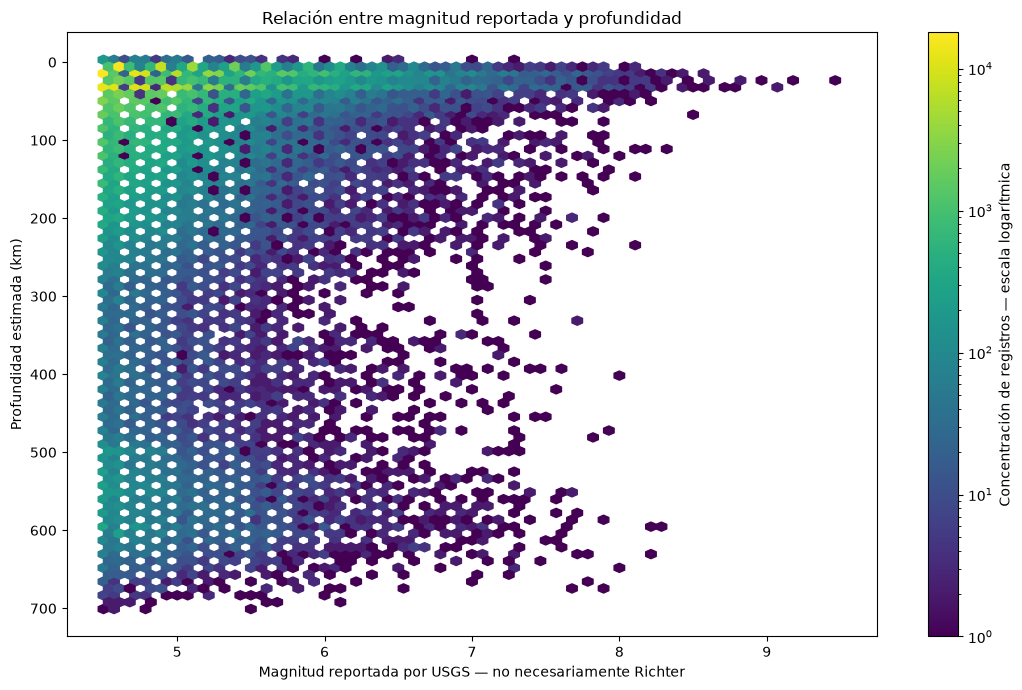

In [13]:
magnitude_depth_correlation = earthquakes[
    ["magnitude", "depth_km"]
].corr(method="spearman").iloc[0, 1]

print(
    "Correlación de Spearman entre magnitud y profundidad:",
    f"{magnitude_depth_correlation:.3f}",
)


depth_group = pd.cut(
    earthquakes["depth_km"],
    bins=[
        float("-inf"),
        0,
        70,
        300,
        float("inf"),
    ],
    labels=[
        "negative_or_zero",
        "shallow_0_70_km",
        "intermediate_70_300_km",
        "deep_over_300_km",
    ],
)

magnitude_by_depth = (
    earthquakes
    .assign(depth_range=depth_group)
    .groupby(
        "depth_range",
        observed=True,
    )
    .agg(
        event_count=("event_id", "size"),
        mean_magnitude=("magnitude", "mean"),
        median_magnitude=("magnitude", "median"),
        maximum_magnitude=("magnitude", "max"),
    )
    .reset_index()
)

display(magnitude_by_depth)


fig, ax = plt.subplots(figsize=(11, 7))

density = ax.hexbin(
    earthquakes["magnitude"],
    earthquakes["depth_km"],
    gridsize=70,
    bins="log",
    mincnt=1,
)

colorbar = fig.colorbar(
    density,
    ax=ax,
)

colorbar.set_label(
    "Concentración de registros — escala logarítmica"
)

ax.invert_yaxis()

ax.set_title(
    "Relación entre magnitud reportada y profundidad"
)
ax.set_xlabel(
    "Magnitud reportada por USGS — no necesariamente Richter"
)
ax.set_ylabel("Profundidad estimada (km)")

plt.tight_layout()
plt.show()

### Relación entre magnitud y profundidad

La correlación de Spearman entre magnitud y profundidad es de `-0.043`.

Este valor está muy próximo a cero, por lo que no se observa una relación
monotónica relevante entre ambas variables dentro del catálogo analizado.
En otras palabras, la profundidad por sí sola no permite anticipar si un
terremoto tendrá una magnitud mayor o menor.

Las magnitudes medias de los diferentes grupos de profundidad también son
similares:

- Profundidad igual o inferior a 0 km: magnitud media de 4.80.
- Entre más de 0 y 70 km: magnitud media de 4.95.
- Entre más de 70 y 300 km: magnitud media de 4.85.
- Más de 300 km: magnitud media de 4.89.

El grupo superficial contiene el terremoto de mayor magnitud del catálogo,
con un valor de 9.5. Sin embargo, también es el grupo con muchos más registros,
por lo que este máximo aislado no demuestra una relación causal entre poca
profundidad y mayor magnitud.

La concentración de puntos cerca de magnitudes entre 4.5 y 5.0 está
condicionada por el filtro mínimo aplicado durante la descarga.

Este análisis describe una asociación estadística. No permite concluir que
la profundidad cause una determinada magnitud.

## Sesgos y riesgos de interpretación

El catálogo procesado es amplio, pero no representa de forma completamente
uniforme todos los terremotos ocurridos en el planeta. Los patrones encontrados
pueden estar condicionados por cómo, dónde y cuándo se registraron los eventos.

### 1. Sesgo temporal

La cobertura del catálogo no es homogénea desde 1900.

Las redes sísmicas, los instrumentos, la digitalización y la capacidad para
detectar terremotos han mejorado con el tiempo. Por tanto, un aumento del número
de registros en décadas recientes no demuestra por sí solo un aumento de la
actividad sísmica mundial.

El año 2026 también está incompleto, porque el dataset termina el 21 de julio.

**Mitigación:**

- No comparar directamente años parciales con años completos.
- No interpretar el número bruto de registros como una medida aislada de la
  evolución de la actividad sísmica.
- Considerar ventanas temporales comparables durante el modelado.

### 2. Sesgo por magnitud mínima

La descarga utiliza una magnitud mínima de 4.5.

Esto mejora la comparabilidad global y reduce el volumen de eventos pequeños,
pero excluye terremotos de menor magnitud. El dataset no representa toda la
sismicidad existente, sino únicamente los eventos que cumplen el umbral
establecido.

Las zonas donde predominan terremotos pequeños pueden quedar infrarrepresentadas.

**Mitigación:**

- Mantener el umbral documentado como una decisión metodológica.
- No interpretar una ausencia de registros como ausencia total de actividad.
- Realizar análisis regionales separados cuando se disponga de catálogos con
  umbrales más bajos.

### 3. Sesgo geográfico y de cobertura de sensores

La capacidad de detección no es idéntica en todo el mundo.

Las regiones con redes sísmicas más densas, mejor instrumentación o mayor
historial de observación pueden disponer de registros más completos que zonas
remotas, oceánicas o con menor infraestructura científica.

Una celda geográfica con pocos eventos puede representar:

- Una actividad sísmica realmente baja.
- Una cobertura instrumental limitada.
- Un catálogo histórico más corto.
- Un umbral de detección diferente.

**Mitigación:**

- No convertir automáticamente la ausencia de eventos en riesgo cero.
- Interpretar la frecuencia junto con la cobertura temporal y la calidad de
  los datos.
- Evitar comparar regiones únicamente mediante conteos absolutos.

### 4. Sesgo por red y método de cálculo

USGS ComCat integra información procedente de distintas redes sísmicas.

Los registros pueden utilizar diferentes métodos de cálculo de magnitud,
criterios de revisión, instrumentos y procedimientos de localización. Por ello,
dos valores numéricos de magnitud no son necesariamente idénticos desde el punto
de vista metodológico.

Solo el 0.79 % del catálogo utiliza magnitud local `ml`, asociada a Richter.
La mayoría utiliza `mb` o variantes de magnitud de momento.

**Mitigación:**

- Conservar siempre `magnitude_type`.
- No denominar todos los valores como escala de Richter.
- Considerar la familia de magnitud al comparar eventos o periodos históricos.

### 5. Sesgo por valores ausentes

Las columnas esenciales del dataset procesado están completas, pero varias
métricas auxiliares tienen una elevada proporción de valores ausentes.

La ausencia de `station_count`, errores de localización u otras métricas no
parece distribuirse necesariamente de forma aleatoria. Puede estar relacionada
con la época, la red de origen o la región geográfica.

**Mitigación:**

- No imputar estos valores automáticamente con una media global.
- No utilizar estas columnas como variables obligatorias sin analizar primero
  su patrón de ausencia.
- Conservar los indicadores de calidad para análisis específicos.

### 6. Sesgo introducido por la limpieza

Durante la limpieza se eliminaron 736 registros:

- 735 por carecer de profundidad.
- 1 por tener magnitud 3.38, inferior al umbral mínimo de 4.5.

La eliminación de registros sin profundidad puede afectar más a determinados
periodos históricos o redes de observación.

**Mitigación:**

- Conservar el dataset bruto para mantener la trazabilidad.
- Documentar la cantidad y la causa de las eliminaciones.
- No ocultar que el dataset procesado representa un subconjunto del catálogo
  descargado.

### 7. Riesgo de trasladar los sesgos al clustering

Si el número de terremotos registrados se utiliza posteriormente para crear
clusters geográficos, el modelo puede aprender diferencias de cobertura
instrumental en lugar de diferencias reales de riesgo.

Una región con muchos sensores podría aparecer artificialmente como más activa,
mientras que una zona con menor cobertura podría clasificarse como de bajo
riesgo.

Este problema sería especialmente relevante si los clusters se utilizaran para
seguros, planificación urbana, inversión o asignación de recursos.

**Mitigación:**

- Incorporar variables relativas al periodo observado y a la calidad de la
  cobertura cuando estén disponibles.
- Utilizar tasas temporales comparables, no solo conteos acumulados.
- Evitar presentar los clusters como predicciones deterministas de seguridad.
- Revisar manualmente regiones con poca cobertura o resultados inesperados.
- Comunicar siempre la incertidumbre y las limitaciones del modelo.

In [14]:
earthquakes["decade"] = (
    earthquakes["timestamp"].dt.year // 10 * 10
)

temporal_bias_summary = (
    earthquakes
    .groupby("decade")
    .agg(
        event_count=("event_id", "size"),
        first_year=("year", "min"),
        last_year=("year", "max"),
        median_magnitude=("magnitude", "median"),
        station_count_available=(
            "station_count",
            lambda values: values.notna().mean() * 100,
        ),
        horizontal_error_available=(
            "horizontal_error_km",
            lambda values: values.notna().mean() * 100,
        ),
        magnitude_error_available=(
            "magnitude_error",
            lambda values: values.notna().mean() * 100,
        ),
    )
    .reset_index()
)

coverage_columns = [
    "station_count_available",
    "horizontal_error_available",
    "magnitude_error_available",
]

temporal_bias_summary[coverage_columns] = (
    temporal_bias_summary[coverage_columns].round(2)
)

display(temporal_bias_summary)

,decade,event_count,first_year,last_year,median_magnitude,station_count_available,horizontal_error_available,magnitude_error_available
0,1900,365,1900,1909,6.65,0.00,0.82,81.92
1,1910,852,1910,1919,6.35,0.00,3.76,93.19
2,1920,1842,1920,1929,6.01,0.00,0.00,99.62
3,1930,2604,1930,1939,5.90,2.88,2.73,97.77
4,1940,1620,1940,1949,6.09,6.11,5.49,98.15
5,1950,2995,1950,1959,5.93,7.31,7.05,97.53
6,1960,4885,1960,1969,5.72,1.72,1.72,97.09
7,1970,25590,1970,1979,5.00,0.70,0.61,10.22
8,1980,39477,1980,1989,4.90,0.90,0.79,0.54
9,1990,43102,1990,1999,4.80,0.64,0.35,0.09


## Conclusiones del análisis exploratorio

El catálogo procesado contiene 308,925 terremotos globales registrados por
USGS entre el 31 de enero de 1900 y el 21 de julio de 2026, con una magnitud
mínima de 4.5.

### Calidad de los datos

- Los 308,925 identificadores son únicos.
- No existen valores ausentes en las columnas esenciales.
- Todas las latitudes y longitudes se encuentran en rangos válidos.
- Durante la limpieza se descartaron 736 registros:
  - 735 por no disponer de profundidad.
  - 1 por tener magnitud 3.38, inferior al umbral mínimo de 4.5.
- Las métricas auxiliares de incertidumbre tienen una cobertura desigual y
  algunos valores extremos, por lo que no deben emplearse sin tratamiento
  adicional.

### Magnitud

- La mediana de magnitud es 4.8.
- El 95.36 % de los eventos tiene una magnitud inferior a 6.0.
- Los eventos clasificados como `major` o `great` representan únicamente
  el 0.51 % del catálogo.
- El valor máximo es 9.5, correspondiente al terremoto de Valdivia de 1960.

La columna `magnitude` no representa una única escala:

- El 75.37 % utiliza magnitud basada en ondas de cuerpo.
- El 21.99 % utiliza variantes de magnitud de momento.
- Solo el 0.79 % utiliza magnitud local `ml`, asociada habitualmente con
  la escala de Richter.

Por tanto, no debe describirse el dataset completo como un catálogo de
magnitudes Richter.

### Profundidad

- La mediana es de 33 km.
- El 77.86 % de los eventos se encuentra entre más de 0 y 70 km.
- El 17.07 % se encuentra entre más de 70 y 300 km.
- El 4.98 % supera los 300 km.
- El 0.09 % presenta profundidades iguales o inferiores a cero.

Los pequeños valores negativos se conservan como estimaciones de eventos
muy superficiales y no se interpretan literalmente como terremotos por
encima de la superficie.

### Relación entre magnitud y profundidad

La correlación de Spearman es de `-0.043`, por lo que no se observa una
relación monotónica relevante entre ambas variables.

La profundidad no permite predecir por sí sola la magnitud de un terremoto
en este catálogo.

### Distribución temporal y geográfica

El número de registros cambia considerablemente a lo largo del periodo
histórico. Esto puede estar influido por la evolución de las redes de
detección, la instrumentación, la cobertura geográfica y la consolidación
de catálogos.

El año 2026 está incompleto, ya que los datos terminan el 21 de julio, y no
debe compararse directamente con años completos.

Geográficamente, los registros se concentran principalmente en zonas
asociadas a límites de placas tectónicas, especialmente alrededor del
océano Pacífico.

### Limitaciones

- El filtro mínimo de magnitud 4.5 condiciona todas las distribuciones.
- La cobertura del catálogo no es uniforme desde 1900.
- Algunas variables técnicas tienen una proporción elevada de valores
  ausentes.
- El mapa representa concentración de terremotos registrados, no riesgo
  geológico.
- El riesgo también depende de exposición, vulnerabilidad, población,
  infraestructuras y condiciones locales.
- Las asociaciones observadas no implican relaciones causales.

## Resumen para la integración con el equipo

### Configuración de la fuente

- Fuente: USGS Earthquake Catalog.
- Cobertura: global.
- Periodo configurado: desde el 1 de enero de 1900 hasta la fecha de ejecución.
- Tipo de evento: `earthquake`.
- Magnitud mínima: 4.5.

### Archivos generados

- Datos originales:
  `data/raw/earthquakes/usgs_earthquakes_raw.csv`
- Datos procesados:
  `data/processed/usgs_earthquakes_clean.csv`
- Pipeline reproducible:
  `src/usgs_earthquakes.py`

### Resultado de la ejecución analizada

- Registros descargados: 309,661.
- Registros procesados: 308,925.
- Registros eliminados: 736.
  - 735 sin profundidad.
  - 1 con magnitud inferior a 4.5.
- Identificadores duplicados en el dataset procesado: 0.
- Nulos en columnas esenciales: 0.

### Columnas principales para la integración

Las columnas recomendadas para unir esta fuente con los demás fenómenos son:

- `event_id`: identificador único.
- `timestamp`: fecha y hora en UTC.
- `lat`: latitud.
- `lon`: longitud.
- `depth_km`: profundidad estimada en kilómetros.
- `magnitude`: valor numérico de magnitud.
- `magnitude_type`: método de cálculo de la magnitud.
- `event_type`: tipo de evento.
- `source`: fuente de los datos.

Las columnas `place`, `network`, `review_status` y las métricas de error pueden
conservarse como información auxiliar.

### Consideraciones para las siguientes fases

- `timestamp` debe utilizarse como fecha común para la integración; está en UTC.
- `timestamp_madrid` es una columna auxiliar de interpretación local.
- No debe denominarse a toda la columna `magnitude` como escala de Richter.
- Los conteos acumulados no deben interpretarse directamente como nivel de
  riesgo.
- Las métricas auxiliares de error tienen muchos valores ausentes y no deben
  utilizarse sin un tratamiento específico.
- La agregación H3, la ingeniería de variables y el clustering quedan fuera
  del alcance de este notebook.